<a href="https://colab.research.google.com/github/molluIdontknow/ELE_Algorithm/blob/%EC%86%A1%EC%9E%AC%ED%98%84/ELEalgo_MLP%EC%9D%98_%EC%82%AC%EB%B3%B8_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Load
실험 Dataset: California housing

In [1]:
import pandas as pd

CSV_FILEPATH = "/content/merged_features_25C.csv"
df = pd.read_csv(CSV_FILEPATH)

print("데이터 크기 (행, 열):", df.shape)
print("\n컬럼 목록:")
for col in df.columns:
    print(" -", col)

df.head()

데이터 크기 (행, 열): (141, 29)

컬럼 목록:
 - cell_global_id
 - rpt_id
 - aging_condition
 - variance
 - xmean
 - mean3839
 - mean3940
 - mean4041
 - mean4142
 - max
 - min
 - range
 - stdev
 - dcirohm
 - dcir_soc00ohm
 - dcir_soc10ohm
 - dcir_soc20ohm
 - dcir_soc30ohm
 - dcir_soc40ohm
 - dcir_soc50ohm
 - dcir_soc60ohm
 - dcir_soc70ohm
 - dcir_soc80ohm
 - deltat023840
 - deltat103840
 - ctr
 - ccct
 - cvct
 - soh_label_pct


,cell_global_id,rpt_id,aging_condition,variance,xmean,mean3839,mean3940,mean4041,mean4142,max,...,dcir_soc50ohm,dcir_soc60ohm,dcir_soc70ohm,dcir_soc80ohm,deltat023840,deltat103840,ctr,ccct,cvct,soh_label_pct
0,1,0,LOW C@ 25°C #1,0.007519,0.294405,0.238540,0.287085,0.247514,0.409893,0.463239,...,0.025000,0.025000,0.021667,0.023333,4140.0,793.333333,0.191626,3140,443.05,100.000000
1,1,1,LOW C@ 25°C #1,0.008914,0.298118,0.253707,0.288757,0.239441,0.416074,0.471264,...,0.026667,0.025000,0.023333,0.023333,4050.0,786.666667,0.194239,2870,455.05,93.108019
2,1,2,LOW C@ 25°C #1,0.009736,0.302310,0.258539,0.295900,0.244835,0.415268,0.472016,...,0.028333,0.026667,0.025000,0.025000,4020.0,770.000000,0.191542,2720,458.15,89.463221
3,1,3,LOW C@ 25°C #1,0.010022,0.302330,0.259584,0.297045,0.245275,0.412607,0.469879,...,0.030000,0.026667,0.026667,0.025000,4000.0,765.000000,0.191250,2650,460.65,87.773360
4,1,4,LOW C@ 25°C #1,0.010921,0.311753,0.267694,0.308545,0.256374,0.419489,0.478524,...,0.030000,0.026667,0.028333,0.028333,4000.0,755.000000,0.188750,2570,475.70,86.249172


# Config

* 라이브러리 불러오기
* hyperparameter 조정

In [2]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)


# hyperparamter 조정
CONFIG = {
    "batch_size": 5,
    "epochs": 1000,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "patience": 10,
    "random_seed": 42
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(CONFIG["random_seed"])

# 기본 실행 코드
MLP 구조: N -> 16 -> 8 ->1

In [3]:
# 데이터셋 클래스 (CSV 파일 읽기)
class BatteryCSVDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# MLP 모델 클래스
class SOHPredictorMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

# Dataset Loader
*   Feature, Target 설정
*   Dataset Split: Train 8 / Val 1 / Test 1




In [4]:
CSV_FILENAME = "merged_features_25C.csv"

# Feature, Target 설정
FEATURES = ["variance", "xmean", "mean4142",
    "max", "min", "range", "stdev", "dcirohm", "dcir_soc50ohm", "deltat023840", "ctr", "ccct", "cvct"]
TARGET = "soh_label_pct"

df = pd.read_csv(CSV_FILENAME)

X = df[FEATURES].values
y = df[TARGET].values

# Dataset Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=CONFIG["random_seed"])

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=CONFIG["random_seed"])

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

train_dataset = BatteryCSVDataset(X_train, y_train)
val_dataset = BatteryCSVDataset(X_val, y_val)
test_dataset = BatteryCSVDataset(X_test, y_test)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False)

# Train/Val/Test 별 Data 개수 출력
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 112
Validation: 14
Test: 15


# Epoch 실행

*   Loss: MSE
*   Optimizer: Adam
*   Weight decay 적용: overfitting 방지
*   Learning rate Scheduler: 기준 5번
*   Early Stopping: 기준 Config에서 설정





In [5]:
model = SOHPredictorMLP(input_dim=len(FEATURES))

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"])

# Learning rate Schedler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

best_val_loss = float("inf")
patience_count = 0

train_losses = []
val_losses = []

# Epoch 실행
for epoch in range(1, CONFIG["epochs"] + 1):

    model.train()
    train_loss = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        pred_y = model(batch_x)
        loss = criterion(pred_y, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for batch_x, batch_y in val_loader:
            pred_y = model(batch_x)
            loss = criterion(pred_y, batch_y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch}/{CONFIG['epochs']}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )


    # best validation 값 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        patience_count = 0

        torch.save(
            model.state_dict(),
            "best_mlp_model.pth")
    else:
        patience_count += 1

    # Early Stopping -> 기준 config에서 설정
    if patience_count >= CONFIG["patience"]:
        print("Early stopping")
        break

Epoch [1/1000] Train Loss: 7920.7533 Val Loss: 7757.6313
Epoch [2/1000] Train Loss: 7908.3548 Val Loss: 7735.4071
Epoch [3/1000] Train Loss: 7876.6539 Val Loss: 7704.0885
Epoch [4/1000] Train Loss: 7874.1284 Val Loss: 7657.1058
Epoch [5/1000] Train Loss: 7799.0515 Val Loss: 7578.6589
Epoch [6/1000] Train Loss: 7711.0522 Val Loss: 7451.1885
Epoch [7/1000] Train Loss: 7553.7882 Val Loss: 7263.8045
Epoch [8/1000] Train Loss: 7327.2784 Val Loss: 7003.8395
Epoch [9/1000] Train Loss: 7028.9083 Val Loss: 6648.8228
Epoch [10/1000] Train Loss: 6708.0655 Val Loss: 6208.5895
Epoch [11/1000] Train Loss: 6225.4621 Val Loss: 5698.2166
Epoch [12/1000] Train Loss: 5725.6159 Val Loss: 5134.4344
Epoch [13/1000] Train Loss: 5131.7315 Val Loss: 4548.9874
Epoch [14/1000] Train Loss: 4495.1664 Val Loss: 3971.0073
Epoch [15/1000] Train Loss: 3950.9413 Val Loss: 3447.4587
Epoch [16/1000] Train Loss: 3360.6455 Val Loss: 2987.0657
Epoch [17/1000] Train Loss: 2811.1212 Val Loss: 2613.4556
Epoch [18/1000] Train L

# Loss Curve




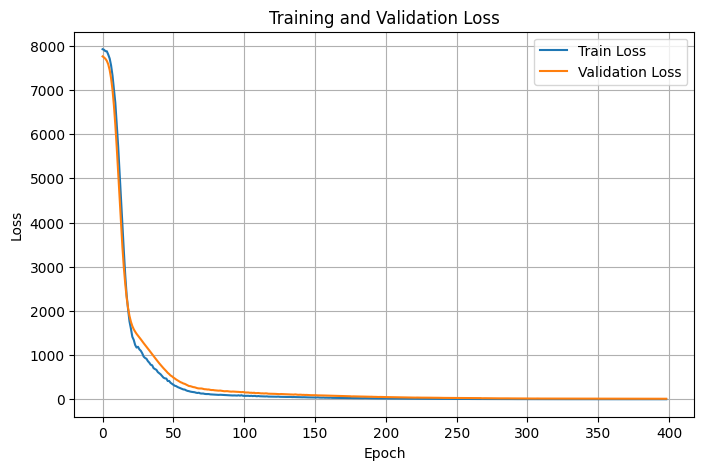

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss")

plt.plot(
    val_losses,
    label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()
plt.show()

# Result

In [7]:
model.load_state_dict(torch.load("best_mlp_model.pth"))
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        pred_y = model(batch_x)

        predictions.extend(pred_y.numpy().flatten())
        actuals.extend(batch_y.numpy().flatten())

predictions = np.array(predictions)
actuals = np.array(actuals)

# Test Loss
test_loss = mean_squared_error(actuals, predictions)

print("Test Loss:", round(test_loss, 4))

# 무작위 10개 결과 확인
random_indices = np.random.choice(
    len(actuals),
    size=10,
    replace=False
)

sample_actuals = actuals[random_indices]
sample_predictions = predictions[random_indices]

abs_error = np.abs(sample_actuals - sample_predictions)
error_rate_pct = (abs_error / np.maximum(np.abs(sample_actuals), 1e-8)) * 100

result_df = pd.DataFrame({
    "Actual": np.round(sample_actuals, 4),
    "Prediction": np.round(sample_predictions, 4),
    "Absolute Error": np.round(abs_error, 4),
    "Error Rate (%)": np.round(error_rate_pct, 2)})

print("\nPrediction Result")
print(result_df.to_string(index=False))

Test Loss: 5.4498

Prediction Result
    Actual  Prediction  Absolute Error  Error Rate (%)
100.000000  100.381798          0.3818            0.38
100.000000   96.734398          3.2656            3.27
 83.449402   80.602600          2.8468            3.41
 86.279701   86.703499          0.4238            0.49
 86.160400   83.547997          2.6124            3.03
 85.138702   86.466202          1.3275            1.56
 88.010498   87.268898          0.7417            0.84
 89.475403   88.615799          0.8596            0.96
 93.386002   94.669098          1.2831            1.37
 93.295700   91.372200          1.9235            2.06
